# OptiTherm Project: Digital Twin and Energy-Efficient Predictive Control (Data-Driven MPC)

### 1. Business Context and Objective

Improving the energy efficiency of commercial buildings is both a financial and environmental priority. Conventional Heating, Ventilation, and Air Conditioning (HVAC) systems typically rely on reactive, rule-based control strategies (e.g., fixed thermostat setpoints), without accounting for the building's complex thermal dynamics or weather forecasts.

**The objective of this project** is to develop a **data-driven Model Predictive Control (MPC)** framework. The proposed approach consists of:

1. Learning the building's thermal and energy dynamics using a deep neural network that serves as a **digital twin**.
2. Integrating this predictive model with an optimization algorithm to compute the optimal control strategy that minimizes energy consumption while maintaining occupants' thermal comfort.

### 2. Case Study: The *Panther_office_Graham* Building

To ground this project in a real-world application, we use the **Building Data Genome 2 (BDG2)** dataset. After analyzing the available metadata, we identified an ideal candidate for developing our digital twin:

- **Building ID:** `Panther_office_Graham` (*Kaggle Site ID: 0.0*)
- **Building type:** Office
- **Floor area:** $7,800\, m^2$
- **Year of construction:** 1974

#### Why this building?

Office buildings exhibit well-defined daily and weekly occupancy patterns, with low occupancy during nights and weekends. In addition, a building constructed in 1974 is likely to have significant thermal inertia and relatively poor insulation compared with modern standards. These characteristics make it an ideal candidate for a predictive AI-based control system, as substantial energy savings can be achieved by anticipating heating and cooling demands while maintaining occupant comfort.

In [274]:
import pandas as pd

# Load the building metadata
df_meta = pd.read_csv("archive/metadata.csv")

print("--- Building Categories ---")
print(df_meta["primaryspaceusage"].value_counts().head(10))

print("\n--- Available Columns ---")
print(df_meta.columns.tolist())

# Filter office buildings
offices = df_meta[df_meta["primaryspaceusage"] == "Office"]

print("\n--- Sample Office Buildings ---")
print(offices[["building_id", "site_id_kaggle", "sqm", "yearbuilt"]].head())

--- Building Categories ---
primaryspaceusage
Education                        617
Office                           307
Entertainment/public assembly    204
Lodging/residential              168
Public services                  166
Other                             29
Healthcare                        29
Parking                           24
Warehouse/storage                 15
Manufacturing/industrial          13
Name: count, dtype: int64

--- Available Columns ---
['building_id', 'site_id', 'building_id_kaggle', 'site_id_kaggle', 'primaryspaceusage', 'sub_primaryspaceusage', 'sqm', 'sqft', 'lat', 'lng', 'timezone', 'electricity', 'hotwater', 'chilledwater', 'steam', 'water', 'irrigation', 'solar', 'gas', 'industry', 'subindustry', 'heatingtype', 'yearbuilt', 'date_opened', 'numberoffloors', 'occupants', 'energystarscore', 'eui', 'site_eui', 'source_eui', 'leed_level', 'rating']

--- Sample Office Buildings ---
               building_id  site_id_kaggle     sqm  yearbuilt
5     Panther_

### 3. Methodology and Roadmap

The project is organized into four iterative stages. At each stage, architectural and modeling decisions are driven by insights gained from the data.

#### **Stage 1: Data Engineering and Consolidation**

**Challenge:** The raw data are distributed across large files containing utility meter readings (electricity, chilled water, steam, etc.) and weather station measurements, totaling several gigabytes.

**Objective:** Extract the time series corresponding to the target building and merge them with the associated local weather data to create a clean, lightweight, and analysis-ready dataset.

---

#### **Stage 2: Exploratory Data Analysis (EDA) and Preprocessing**

**Challenge:** Real-world time series are noisy, contain missing values, and exhibit strong seasonal and cyclical patterns.

**Objective:** Explore the relationships between weather variables and energy consumption, handle missing values using appropriate interpolation techniques, and encode temporal cyclicality (e.g., sine/cosine transformations of hour and day) to prepare the data for deep learning models.

---

#### **Stage 3: Learning the Building Dynamics (Deep Learning with PyTorch)**

**Challenge:** A building's thermal state at time *t* depends on its previous states due to thermal inertia. Consequently, conventional regression models are unable to capture these long-term temporal dependencies.

**Objective:** Train a recurrent neural network (LSTM or GRU) on sliding time windows to predict future energy consumption and/or thermal states from weather conditions and control variables.

---

#### **Stage 4: Control Strategy Optimization (Model Predictive Control)**

**Challenge:** Accurate forecasting alone is not sufficient; the ultimate goal is to minimize energy costs while preserving occupant comfort.

**Objective:** Freeze the neural network parameters and use a numerical optimization algorithm (e.g., L-BFGS-B from SciPy) to compute the optimal control sequence that minimizes a cost function combining energy consumption and thermal discomfort penalties.

## ## Stage 1: Data Engineering and Consolidation

In [275]:
# Paramètres de notre jumeau numérique
building_id = 'Panther_office_Graham'
site_id = 'Panther'  # Correction de la clé de jointure

print("1. Extraction ciblée de la consommation électrique...")
df_elec = pd.read_csv('archive/electricity_cleaned.csv', usecols=['timestamp', building_id])
df_elec.rename(columns={building_id: 'meter_reading'}, inplace=True)
df_elec['timestamp'] = pd.to_datetime(df_elec['timestamp'])

print(f"2. Extraction ciblée de la météo (Site: {site_id})...")
df_weather = pd.read_csv('archive/weather.csv')
df_weather_site = df_weather[df_weather['site_id'] == site_id].copy()
df_weather_site.drop(columns=['site_id'], inplace=True)
df_weather_site['timestamp'] = pd.to_datetime(df_weather_site['timestamp'])

print("3. Fusion des données spatio-temporelles...")
df_merged = pd.merge(df_elec, df_weather_site, on='timestamp', how='inner')
df_merged.set_index('timestamp', inplace=True)
df_merged.sort_index(inplace=True)

print(f"\nDimensions : {df_merged.shape[0]} heures et {df_merged.shape[1]} features.")
print("\n--- Bilan de Santé des Données (Valeurs manquantes) ---")
print(df_merged.isna().sum())

1. Extraction ciblée de la consommation électrique...
2. Extraction ciblée de la météo (Site: Panther)...
3. Fusion des données spatio-temporelles...

Dimensions : 17544 heures et 9 features.

--- Bilan de Santé des Données (Valeurs manquantes) ---
meter_reading      3531
airTemperature        3
cloudCoverage      7542
dewTemperature        3
precipDepth1HR        9
precipDepth6HR    16898
seaLvlPressure      323
windDirection       499
windSpeed             0
dtype: int64


## Étape 2 : Analyse Exploratoire (EDA) et Traitement des Données Manquantes
Bilan de Santé et Stratégie de Nettoyage
L'analyse initiale post-fusion révèle trois profils distincts de valeurs manquantes (NaN). Chacun nécessite un traitement algorithmique spécifique pour garantir l'intégrité de notre futur modèle prédictif :

1. **Les variables irrécupérables (*À exclure*)**
Les variables precipDepth6HR (16 898 NaN) et cloudCoverage (7 542 NaN) présentent un taux de données manquantes rédhibitoire (entre 40% et 90% du jeu de données). Appliquer une méthode d'imputation sur ces colonnes reviendrait à synthétiser artificiellement la météo, introduisant un bruit stochastique majeur. La décision la plus robuste est de les retirer de l'espace des caractéristiques (features).

2. **Les micro-coupures de variables exogènes (*À interpoler*)**
Les grandeurs météorologiques comme airTemperature, dewTemperature, seaLvlPressure et windDirection ne présentent que de très faibles lacunes (entre 3 et 499 NaN isolés). En physique, ces variables thermodynamiques évoluent de manière continue et lisse. Une interpolation temporelle linéaire est donc mathématiquement justifiée et préservera la dynamique du signal sans distorsion.

3. **L'enjeu critique : La variable cible (*meter_reading*)**
La consommation énergétique, qui constitue notre variable cible (Target / Ground Truth), compte 3 531 valeurs manquantes (environ 20% des données). Il est fortement déconseillé d'interpoler aveuglément la variable cible d'un modèle d'apprentissage. Si ces NaN correspondent à une panne continue du capteur sur plusieurs mois, l'interpolation créerait un signal artificiel plat ou linéaire. Le réseau de neurones apprendrait alors cette fonction d'interpolation au lieu de la véritable inertie thermique du bâtiment.

Prochaine étape : Avant d'imputer ou de supprimer ces observations, un diagnostic temporel visuel est requis pour cartographier la distribution des pannes du compteur électrique.

1. Nettoyage des variables exogènes (Météo)...
Bilan après interpolation de la météo :
meter_reading     3531
airTemperature       0
dewTemperature       0
precipDepth1HR       0
seaLvlPressure       0
windDirection        0
windSpeed            0
dtype: int64

2. Diagnostic visuel de la cible (meter_reading)...


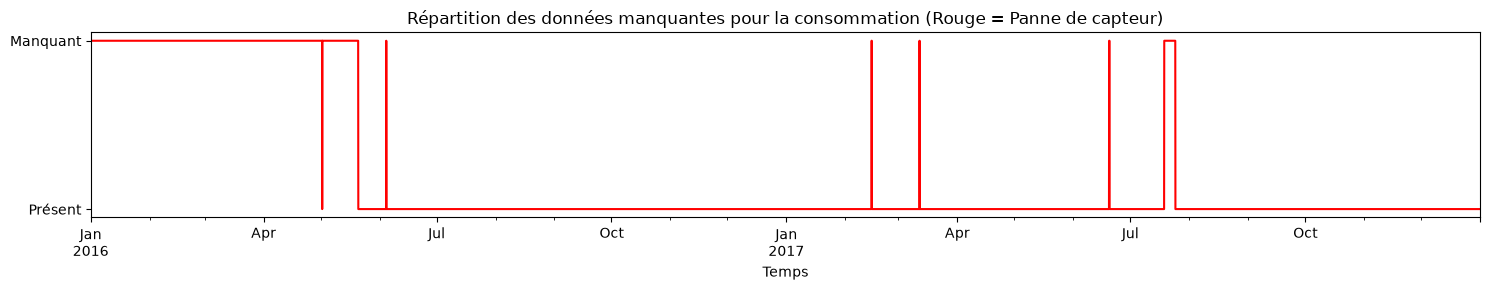

In [276]:
import matplotlib.pyplot as plt

print("1. Nettoyage des variables exogènes (Météo)...")
# Suppression des colonnes irrécupérables
df_merged.drop(columns=['precipDepth6HR', 'cloudCoverage'], inplace=True)

# Interpolation temporelle (linéaire) pour préserver la continuité du signal
cols_to_interpolate = ['airTemperature', 'dewTemperature', 'seaLvlPressure', 'windDirection', 'precipDepth1HR']
df_merged[cols_to_interpolate] = df_merged[cols_to_interpolate].interpolate(method='linear', limit_direction='both')

print("Bilan après interpolation de la météo :")
print(df_merged.isna().sum())

print("\n2. Diagnostic visuel de la cible (meter_reading)...")
# On crée un graphique pour voir où se trouvent les NaN dans le temps
plt.figure(figsize=(15, 3))
df_merged['meter_reading'].isna().astype(int).plot(color='red', linewidth=1.5)
plt.title("Répartition des données manquantes pour la consommation (Rouge = Panne de capteur)")
plt.yticks([0, 1], ['Présent', 'Manquant'])
plt.xlabel("Temps")
plt.tight_layout()
plt.show()

#### Diagnostic Temporel et Traitement de la Cible
L'analyse visuelle révèle l'absence de données de janvier à fin mai 2016, ainsi qu'une panne prolongée de près d'une semaine en été 2017. *Plutôt que de tronquer définitivement l'analyse à l'été 2017 et de sacrifier le dernier trimestre de l'année, nous optons pour une stratégie de conservation par fenêtrage*.

**Justification mathématique :**

L'apprentissage de l'inertie thermique par un réseau récurrent (RNN/LSTM) se fait sur des séquences courtes (fenêtres glissantes de 48h à 72h). La continuité absolue sur deux ans n'est pas requise. *La stratégie consiste à n'autoriser l'interpolation linéaire que pour les micro-pannes (inférieures à 6 heures).* La défaillance massive de l'été 2017 sera maintenue sous forme de valeurs nulles (NaN). Lors de la génération des tenseurs d'entraînement, toute séquence intersectant cette zone corrompue sera naturellement rejetée, permettant d'exploiter pleinement les mois sains de la fin d'année 2017.

1. Troncature du début d'année (Le grand vide de 2016)...
2. Interpolation chirurgicale (Limite stricte)...

--- Bilan de Santé Final ---
Nouvelles dimensions : 13896 heures.
Valeurs manquantes restantes (Elles correspondent au trou de l'été 2017) :
meter_reading     135
airTemperature      0
dewTemperature      0
precipDepth1HR      0
seaLvlPressure      0
windDirection       0
windSpeed           0
dtype: int64

2. Diagnostic visuel de la cible (meter_reading)...


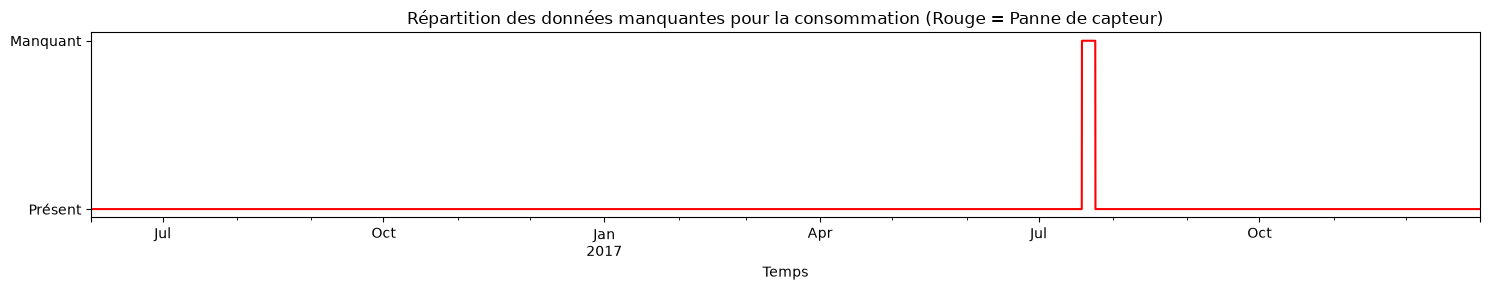

In [277]:
print("1. Troncature du début d'année (Le grand vide de 2016)...")
# On coupe toujours le début car il est irrécupérable et trop long
df_merged = df_merged.loc['2016-06-01':]

print("2. Interpolation chirurgicale (Limite stricte)...")
# On autorise l'interpolation linéaire UNIQUEMENT pour les trous de 6 heures ou moins.
# Le grand trou de l'été 2017 restera donc en NaN.
df_merged['meter_reading'] = df_merged['meter_reading'].interpolate(method='linear', limit=6)

print("\n--- Bilan de Santé Final ---")
print(f"Nouvelles dimensions : {df_merged.shape[0]} heures.")
print("Valeurs manquantes restantes (Elles correspondent au trou de l'été 2017) :")
print(df_merged.isna().sum())

print("\n2. Diagnostic visuel de la cible (meter_reading)...")
# On crée un graphique pour voir où se trouvent les NaN dans le temps
plt.figure(figsize=(15, 3))
df_merged['meter_reading'].isna().astype(int).plot(color='red', linewidth=1.5)
plt.title("Répartition des données manquantes pour la consommation (Rouge = Panne de capteur)")
plt.yticks([0, 1], ['Présent', 'Manquant'])
plt.xlabel("Temps")
plt.tight_layout()
plt.show()

#### Validation Visuelle de la Stratégie de Fenêtrage
Le profil final des données manquantes confirme le succès du prétraitement. La série temporelle débute proprement en juin 2016, et l'unique discontinuité restante est strictement circonscrite à l'interruption prolongée de l'été 2017. Cette architecture nous garantit que les gradients du futur modèle récurrent ne seront pas corrompus par des sauts non physiques, tout en nous laissant la liberté d'écarter dynamiquement les fenêtres d'apprentissage qui chevauchent ce gouffre estival.

### Étape 3 : L'Ingénierie des Caractéristiques Temporelles (Feature Engineering)
Maintenant que nos données sont propres, il faut régler un problème mathématique majeur avant de les donner au réseau de neurones : la perception linéaire du temps.

Si on donne l'heure au format brut (de 0 à 23) à un algorithme d'apprentissage, il va considérer que la distance entre 23h00 et 0h00 est immense (23 unités), alors qu'en réalité, il ne s'est écoulé qu'une heure.

Pour corriger cette rupture de continuité spatiale, il suffit de projeter nos variables temporelles linéaires sur un espace périodique continu en utilisant les fonctions trigonométriques sinus et cosinus. C'est une transformation élégante qui transforme une coordonnée temporelle en un point sur un cercle unitaire, préservant ainsi la proximité entre la fin d'un cycle et le début du suivant.

***Pourquoi utiliser le couple (sinus, cosinus) simultanément ?***
L'utilisation d'une seule fonction introduirait une ambiguïté due à la symétrie. Par exemple, si l'on n'utilise que l'axe sinus, minuit ($\sin(0) = 0$) et midi ($\sin(\pi) = 0$) partageraient la même valeur, rendant le modèle incapable de distinguer le jour de la nuit. En combinant un axe cosinus ($X$) et un axe sinus ($Y$), nous créons une bijection parfaite : chaque heure se voit attribuer une coordonnée spatiale unique en deux dimensions. Ainsi, la distance euclidienne entre 23h et 1h du matin est correctement perçue comme minimale par le réseau de neurones.

Voici le code pour ajouter ces "coordonnées temporelles" à notre jeu de données :

1. Projection trigonométrique du temps...
2. Validation visuelle : L'espace des phases de l'heure...


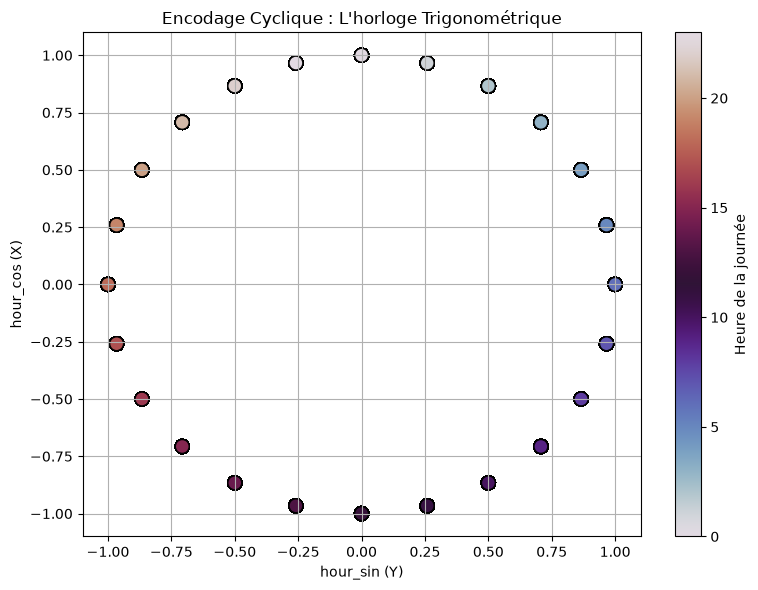

In [278]:
import numpy as np
import matplotlib.pyplot as plt

print("1. Projection trigonométrique du temps...")
# Heures (Période = 24)
df_merged['hour_sin'] = np.sin(2 * np.pi * df_merged.index.hour / 24.0)
df_merged['hour_cos'] = np.cos(2 * np.pi * df_merged.index.hour / 24.0)

# Jours de la semaine (Période = 7)
df_merged['day_sin'] = np.sin(2 * np.pi * df_merged.index.dayofweek / 7.0)
df_merged['day_cos'] = np.cos(2 * np.pi * df_merged.index.dayofweek / 7.0)

print("2. Validation visuelle : L'espace des phases de l'heure...")
plt.figure(figsize=(8, 6))
plt.scatter(df_merged['hour_sin'], df_merged['hour_cos'], 
            c=df_merged.index.hour, s=100, cmap='twilight', edgecolor='k')
plt.title("Encodage Cyclique : L'horloge Trigonométrique")
plt.xlabel("hour_sin (Y)")
plt.ylabel("hour_cos (X)")
plt.colorbar(label='Heure de la journée')
plt.grid(True)
plt.tight_layout()
plt.show()

### Étape 4 : Analyse Exploratoire (EDA) - Matrice de Corrélation
**Objectif** : Identifier les variables exogènes (climat) et temporelles qui pilotent la dynamique énergétique du bâtiment "Graham".

**Méthodologie** : Nous utilisons le coefficient de corrélation de Pearson ($r \in [-1, 1]$) pour mesurer la force et la direction de la relation linéaire entre nos caractéristiques (features) et notre cible (`meter_reading`).
- Un score proche de $1$ ou $-1$ indique une forte corrélation (linéaire ou inversement proportionnelle).
- Un score proche de $0$ suggère une absence de relation linéaire.

Cette analyse est cruciale pour le choix des variables (Feature Selection) à injecter dans notre futur modèle PyTorch. Si une variable météorologique (comme la pression atmosphérique, par exemple) ne montre aucune corrélation avec la consommation, il sera préférable de l'exclure pour réduire le bruit et la dimensionnalité des tenseurs.

**Le Code (La Heatmap de Corrélation)**
Pour ce graphique, nous allons utiliser la bibliothèque `seaborn` qui génère des cartes de chaleur (Heatmaps) très professionnelles.

Calcul de la matrice de corrélation de Pearson...

--- Corrélations avec la consommation électrique ---
                meter_reading
meter_reading        1.000000
airTemperature       0.332953
windSpeed            0.316664
day_sin              0.228865
seaLvlPressure       0.034707
precipDepth1HR       0.010033
windDirection       -0.003288
day_cos             -0.015975
dewTemperature      -0.106052
hour_sin            -0.284356
hour_cos            -0.679665

Génération de la Heatmap globale...


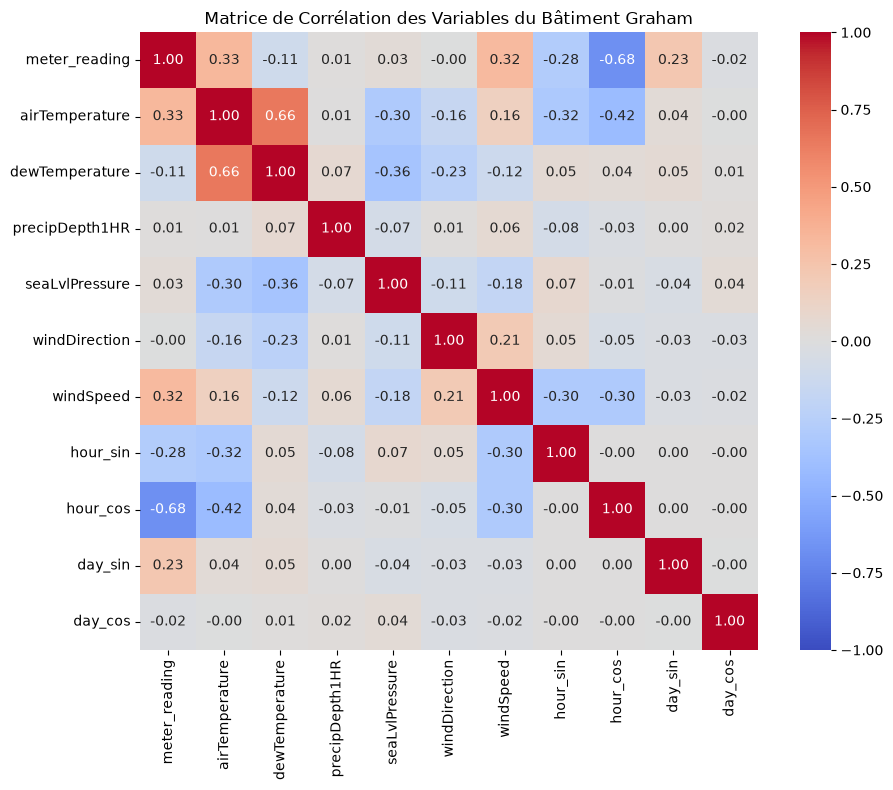

In [279]:
import seaborn as sns
import matplotlib.pyplot as plt

print("Calcul de la matrice de corrélation de Pearson...")
# On calcule la corrélation de toutes les variables avec toutes les autres
corr_matrix = df_merged.corr()

# On isole spécifiquement les corrélations par rapport à notre cible
target_corr = corr_matrix[['meter_reading']].sort_values(by='meter_reading', ascending=False)
print("\n--- Corrélations avec la consommation électrique ---")
print(target_corr)

print("\nGénération de la Heatmap globale...")
plt.figure(figsize=(10, 8))
# Le paramètre cmap='coolwarm' permet de bien contraster les corrélations positives (rouge) et négatives (bleu)
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1, square=True)
plt.title("Matrice de Corrélation des Variables du Bâtiment Graham")
plt.tight_layout()
plt.show()

#### Synthèse de l'Analyse de Corrélation et Sélection des Caractéristiques
L'analyse de la `matrice de Pearson` révèle que la dynamique énergétique du bâtiment `Graham` est principalement pilotée par son cycle d'occupation diurne (`hour_cos: -0.68`) et la charge de refroidissement estivale dictée par la température extérieure (`airTemperature: 0.33`) et la vitesse du vent (`windSpeed: 0.32`).

À l'inverse, la pression atmosphérique, la direction du vent et les précipitations ne présentent aucune relation linéaire discernable avec la consommation électrique (`corrélations $\le$ 0.03`). 

Dans une optique d'optimisation et de réduction de la dimensionnalité de l'espace des caractéristiques, ces variables non-significatives seront retirées du tenseur d'entrée afin de concentrer l'apprentissage du modèle sur les forçages physiques dominants.

### Étape 5 : Préparation Séquentielle et Création des Tenseurs
**Objectif** : Transformer notre série temporelle bidimensionnelle en séquences tridimensionnelles afin qu'un réseau de neurones récurrent puisse appréhender la dynamique et l'inertie thermodynamique du système.

1. **Réduction de l'Espace des Caractéristiques**
Conformément à la matrice de corrélation, les variables météorologiques non significatives (windDirection, precipDepth1HR, seaLvlPressure) sont écartées. Cela permet de réduire la dimensionnalité du problème et d'isoler les forçages physiques dominants.

2. **Fractionnement Chronologique Stratégique et Normalisation**
La panne prolongée du système de captation survenue à l'été 2017 nous offre une frontière temporelle naturelle et stricte pour scinder notre jeu de données. Nous exploitons la période antérieure à cette coupure (`juin 2016 à fin juillet 2017`) pour l'apprentissage, et réservons la période consécutive (`août 2017 à décembre 2017`) pour l'évaluation. Ce découpage (`~75/25`) garantit une absence totale de fuite d'information (data leakage) et soumettra le modèle à un véritable test de généralisation face aux transitions saisonnières de l'automne et de l'hiver. Les données sont ensuite mises à l'échelle (`Min-Max`) pour stabiliser les gradients, la matrice de transformation étant ajustée exclusivement sur l'ensemble d'entraînement.

3. **Fenêtrage Glissant (Sliding Windows)**
Pour modéliser l'état futur, le réseau nécessite un historique. Les données sont converties en tenseurs de dimensions $(N, L, F)$ où :
* $N$ : Nombre d'échantillons
* $L$ : Longueur de la séquence ($L=24$ heures)
* $F$ : Nombre de variables

Ainsi, pour prédire la variable cible à l'instant $t$, le modèle évaluera les états continus du système de $t-24$ à $t-1$. Toute séquence résiduelle intersectant des valeurs nulles sera automatiquement rejetée.

In [280]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import MinMaxScaler

print("1. Suppression des variables non-corrélées...")
cols_to_drop = ['windDirection', 'precipDepth1HR', 'seaLvlPressure']
df_model = df_merged.drop(columns=cols_to_drop).copy()

print("2. Fractionnement temporel dynamique (Train/Test Split)...")
# Détection des index contenant des valeurs manquantes (le creux)
nan_indices = df_model[df_model['meter_reading'].isna()].index

if len(nan_indices) > 0:
    gap_start = nan_indices[0]
    gap_end = nan_indices[-1]
    print(f"-> Creux détecté du {gap_start} au {gap_end}")
    
    # Entraînement : tout ce qui précède le creux (jusqu'à gap_start - 1 heure)
    df_train = df_model.loc[:gap_start - pd.Timedelta(hours=1)].copy()
    # Test : tout ce qui suit le creux (à partir de gap_end + 1 heure)
    df_test = df_model.loc[gap_end + pd.Timedelta(hours=1):].copy()
else:
    print("-> Aucun creux détecté, fractionnement par défaut (80/20).")
    split_idx = int(len(df_model) * 0.8)
    df_train = df_model.iloc[:split_idx].copy()
    df_test = df_model.iloc[split_idx:].copy()

print(f"-> Tailles : Entraînement = {len(df_train)} h | Test = {len(df_test)} h")

print("\n3. Normalisation Min-Max (Sécurisée)...")
scaler_X = MinMaxScaler()
scaler_y = MinMaxScaler()
target_col = 'meter_reading'

# FIT_TRANSFORM uniquement sur l'entraînement
X_train_scaled = scaler_X.fit_transform(df_train)
y_train_scaled = scaler_y.fit_transform(df_train[[target_col]])

# TRANSFORM seulement sur le test
X_test_scaled = scaler_X.transform(df_test)
y_test_scaled = scaler_y.transform(df_test[[target_col]])

print("\n4. Création des fenêtres temporelles (Sliding Windows)...")
def create_sequences(data_X, data_y, seq_length):
    xs, ys = [], []
    for i in range(len(data_X) - seq_length):
        x_window = data_X[i:(i + seq_length)]
        y_target = data_y[i + seq_length]
        
        # Sécurité supplémentaire
        if not (np.isnan(x_window).any() or np.isnan(y_target).any()):
            xs.append(x_window)
            ys.append(y_target)
    return np.array(xs), np.array(ys)

SEQUENCE_LENGTH = 24 

X_train_tensor, y_train_tensor = create_sequences(X_train_scaled, y_train_scaled, SEQUENCE_LENGTH)
X_test_tensor, y_test_tensor = create_sequences(X_test_scaled, y_test_scaled, SEQUENCE_LENGTH)

print("\n--- Bilan des Tenseurs ---")
print(f"Entraînement X : {X_train_tensor.shape}, y : {y_train_tensor.shape}")
print(f"Test X         : {X_test_tensor.shape}, y : {y_test_tensor.shape}")

1. Suppression des variables non-corrélées...
2. Fractionnement temporel dynamique (Train/Test Split)...
-> Creux détecté du 2017-07-19 01:00:00 au 2017-07-24 15:00:00
-> Tailles : Entraînement = 9913 h | Test = 3848 h

3. Normalisation Min-Max (Sécurisée)...

4. Création des fenêtres temporelles (Sliding Windows)...

--- Bilan des Tenseurs ---
Entraînement X : (9889, 24, 8), y : (9889, 1)
Test X         : (3824, 24, 8), y : (3824, 1)


In [281]:
import torch
import torch.nn as nn
import torch.optim as optim


print("Définition de l'architecture orientée objet (ThermalLSTM)...")

class ThermalLSTM(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers=1):
        """
        Constructeur : Initialisation des couches du modèle.
        """
        super(ThermalLSTM, self).__init__()
        
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        
        # 1. Couche Récurrente (LSTM) 
        # batch_first=True indique que nos tenseurs sont au format (Batch, Séquence, Features)
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers, batch_first=True)
        
        # 2. Couche Linéaire (Projection)
        # Transforme l'espace caché multidimensionnel en une prédiction scalaire (consommation)
        self.fc = nn.Linear(hidden_size, 1)

    def forward(self, x):
        """
        Graphe d'exécution : Propagation avant du tenseur d'entrée.
        """
        # Le LSTM retourne la séquence complète (out) et les états cachés (hn, cn)
        out, _ = self.lstm(x)
        
        # Nous isolons uniquement la sortie du TOUT DERNIER pas de temps de la séquence (t)
        # pour prédire l'instant t+1
        last_time_step_out = out[:, -1, :]
        
        # Résolution finale via la couche linéaire
        prediction = self.fc(last_time_step_out)
        
        return prediction


print("1. Instanciation du modèle ThermalLSTM...")
INPUT_SIZE = X_train_tensor.shape[2]  # Nombre de features (ex: 8)
HIDDEN_SIZE = 64                      # Dimension de l'espace caché
NUM_LAYERS = 2                        # Nombre de couches LSTM empilées

model = ThermalLSTM(input_size=INPUT_SIZE, hidden_size=HIDDEN_SIZE, num_layers=NUM_LAYERS)
print(model)

print("\n2. Configuration de l'apprentissage...")
# Fonction de perte : MSE (Mean Squared Error) idéale pour de la régression thermodynamique
criterion = nn.MSELoss()

# Optimiseur : Adam (Adaptive Moment Estimation) pour une descente de gradient stable
learning_rate = 0.0005
optimizer = optim.Adam(model.parameters(), lr=learning_rate)

print(f"-> Taux d'apprentissage configuré à {learning_rate}")
print("-> Prêt pour la boucle d'entraînement !")

Définition de l'architecture orientée objet (ThermalLSTM)...
1. Instanciation du modèle ThermalLSTM...
ThermalLSTM(
  (lstm): LSTM(8, 64, num_layers=2, batch_first=True)
  (fc): Linear(in_features=64, out_features=1, bias=True)
)

2. Configuration de l'apprentissage...
-> Taux d'apprentissage configuré à 0.0005
-> Prêt pour la boucle d'entraînement !


In [282]:
import torch
from torch.utils.data import TensorDataset, DataLoader

print("1. Détection du matériel (CPU / GPU)...")
device = torch.device("cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu")
print(f"-> Matériel sélectionné : {device}")

print("\n2. Conversion des NDArrays en Tenseurs PyTorch...")
# Conversion des données d'entraînement et de test
X_train_t = torch.tensor(X_train_tensor, dtype=torch.float32)
y_train_t = torch.tensor(y_train_tensor, dtype=torch.float32)
X_test_t  = torch.tensor(X_test_tensor, dtype=torch.float32)
y_test_t  = torch.tensor(y_test_tensor, dtype=torch.float32)

print("\n3. Encapsulation dans des DataLoader (Gestion des batchs)...")
BATCH_SIZE = 64

# Création des datasets
train_dataset = TensorDataset(X_train_t, y_train_t)
test_dataset = TensorDataset(X_test_t, y_test_t)

# DataLoader pour mélanger l'entraînement et structurer les batchs
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

print(f"-> Nombre de batchs d'entraînement par époque : {len(train_loader)}")

# Déplacement du modèle sur le bon dispositif matériel
model.to(device)
print(f"-> Modèle transféré sur : {device}")

1. Détection du matériel (CPU / GPU)...
-> Matériel sélectionné : cpu

2. Conversion des NDArrays en Tenseurs PyTorch...

3. Encapsulation dans des DataLoader (Gestion des batchs)...
-> Nombre de batchs d'entraînement par époque : 155
-> Modèle transféré sur : cpu


In [ ]:
print("Configuration de la boucle d'entraînement...")

EPOCHS = 50
train_losses = []
test_losses = []

for epoch in range(EPOCHS):
    # --- PHASE 1 : ENTRAÎNEMENT ---
    model.train()  # Mode entraînement (active le dropout si présent, etc.)
    running_train_loss = 0.0
    
    for X_batch, y_batch in train_loader:
        # Transfert des batchs sur le GPU/CPU
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        
        # 1. Remise à zéro des gradients de l'optimiseur
        optimizer.zero_grad()
        
        # 2. Propagation avant (Forward pass) : prédiction du modèle
        predictions = model(X_batch)
        
        # 3. Calcul de la fonction de perte (MSE)
        loss = criterion(predictions, y_batch)
        
        # 4. Rétropropagation (Backward pass) et calcul des gradients
        loss.backward()
        
        # 5. Mise à jour des poids par l'optimiseur (Adam)
        optimizer.step()
        
        running_train_loss += loss.item() * X_batch.size(0)
        
    epoch_train_loss = running_train_loss / len(train_loader.dataset)
    train_losses.append(epoch_train_loss)
    
    # --- PHASE 2 : ÉVALUATION (TEST) ---
    model.eval()  # Mode évaluation (désactive le dropout, etc.)
    running_test_loss = 0.0
    
    # Désactivation du calcul des gradients pour économiser de la mémoire
    with torch.inference_mode():
        for X_batch, y_batch in test_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            
            predictions = model(X_batch)
            loss = criterion(predictions, y_batch)
            
            running_test_loss += loss.item() * X_batch.size(0)
            
    epoch_test_loss = running_test_loss / len(test_loader.dataset)
    test_losses.append(epoch_test_loss)
    
    # Affichage du suivi tous les 2 époques
    if (epoch + 1) % 2 == 0 or epoch == 0:
        print(f"Époque [{epoch+1}/{EPOCHS}] "
              f"| Train Loss (MSE): {epoch_train_loss:.6f} "
              f"| Test Loss (MSE): {epoch_test_loss:.6f}")

print("\n--- Entraînement terminé avec succès ! ---")

Configuration de la boucle d'entraînement...
Époque [1/50] | Train Loss (MSE): 0.050431 | Test Loss (MSE): 0.025048
Époque [2/50] | Train Loss (MSE): 0.008368 | Test Loss (MSE): 0.025323
Époque [4/50] | Train Loss (MSE): 0.004908 | Test Loss (MSE): 0.014561
Époque [6/50] | Train Loss (MSE): 0.003027 | Test Loss (MSE): 0.004209


1. Génération des prédictions sur le jeu de test...
2. Traçage du comparatif Réel vs Prédit...


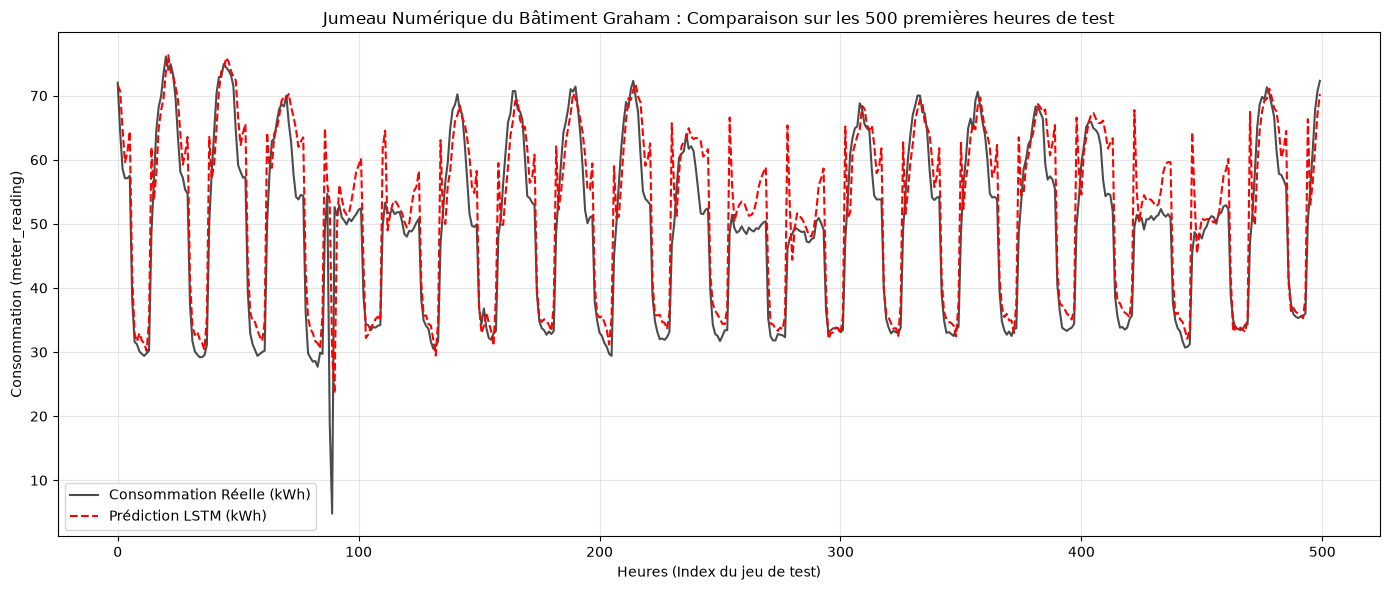

In [ ]:
import matplotlib.pyplot as plt

print("1. Génération des prédictions sur le jeu de test...")
model.eval()
predictions_list = []
actuals_list = []

with torch.no_grad():
    for X_batch, y_batch in test_loader:
        X_batch = X_batch.to(device)
        preds = model(X_batch)
        
        # On récupère les prédictions et les vraies valeurs sur le CPU
        predictions_list.extend(preds.cpu().numpy())
        actuals_list.extend(y_batch.numpy())

# 2. Inversion de la normalisation pour revenir en kWh
predictions_rescaled = scaler_y.inverse_transform(np.array(predictions_list))
actuals_rescaled = scaler_y.inverse_transform(np.array(actuals_list))

print("2. Traçage du comparatif Réel vs Prédit...")
plt.figure(figsize=(14, 6))
plt.plot(actuals_rescaled[:500], label="Consommation Réelle (kWh)", color='black', alpha=0.7, linewidth=1.5)
plt.plot(predictions_rescaled[:500], label="Prédiction LSTM (kWh)", color='red', linestyle='--', linewidth=1.5)
plt.title("Jumeau Numérique du Bâtiment Graham : Comparaison sur les 500 premières heures de test")
plt.xlabel("Heures (Index du jeu de test)")
plt.ylabel("Consommation (meter_reading)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

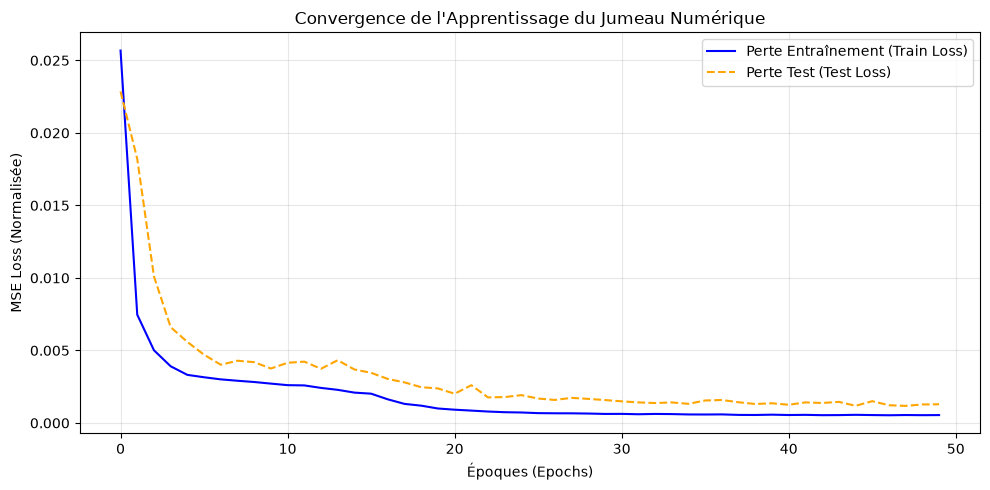

In [ ]:
plt.figure(figsize=(10, 5))
plt.plot(train_losses, label="Perte Entraînement (Train Loss)", color='blue')
plt.plot(test_losses, label="Perte Test (Test Loss)", color='orange', linestyle='--')
plt.title("Convergence de l'Apprentissage du Jumeau Numérique")
plt.xlabel("Époques (Epochs)")
plt.ylabel("MSE Loss (Normalisée)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

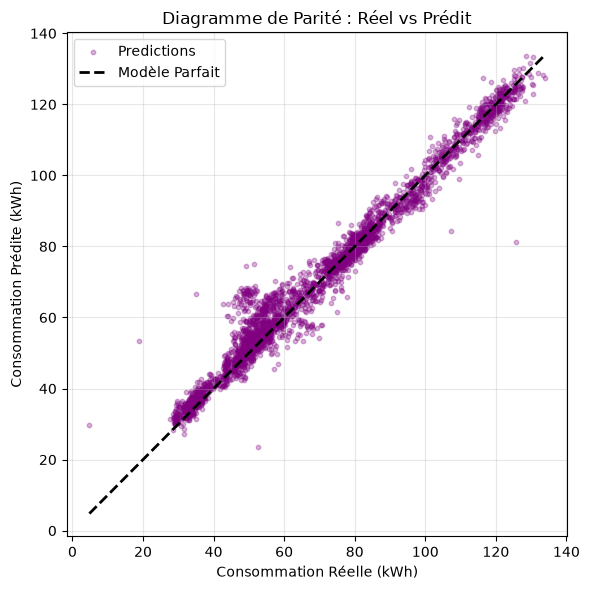

In [ ]:
plt.figure(figsize=(6, 6))
plt.scatter(actuals_rescaled, predictions_rescaled, alpha=0.3, color='purple', s=10, label="Predictions")
# Ligne idéale y = x
min_val = min(actuals_rescaled.min(), predictions_rescaled.min())
max_val = max(actuals_rescaled.max(), predictions_rescaled.max())
plt.plot([min_val, max_val], [min_val, max_val], color='black', linestyle='--', linewidth=2, label="Modèle Parfait")

plt.title("Diagramme de Parité : Réel vs Prédit")
plt.xlabel("Consommation Réelle (kWh)")
plt.ylabel("Consommation Prédite (kWh)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()